# Steane Circ Level Noise (single round)

Data generation and analysis
+ different decoder: ML, MWPM
+ different observables: Z,X
+ different distances
+ different noise levels

analysis: 
+ show asymptotic behavior (not important)
+ determine thresholds


In [13]:
import os
import numpy as np
import matplotlib.pyplot as plt

from tools.file import write_config, smart_read_folder
from tools.combined import generate_new_data_from_config_file
from tools.analysis import data_pre_processing, determine_threshold, data_plot_log_error_rates, data_plot_fssa_results

from tools.parameter import PATH_TO_CONFIG_FOLDER


## Config Defintions and Data Generation

Steane circ (order 0p) with only 1 QEC round (both log X and Z observable)

Circ noise with different noise levels

Decoding both in ML and MWPM


In [14]:
# General parameter
expected_p_th_log = -1.7
width = 0.5
noise_rates = [float(x) for x in np.logspace(expected_p_th_log - width , expected_p_th_log + width,dtype=float)]
distances = [3,5,7,9,11,13,15] # 3 is newly included not yet in data
qec_rounds = [1,]
order = "0p"
circuit_type = "steane"
noise_model_type = "circ"

# Main parameters
num_shots_ML = 1_000
decoder_type_ML = "ml"
# 30 min
# 700 min + for 100_000 data
num_shots_MWPM = 10_000
decoder_type_MWPM = "mwpm"

# Z config
observable_Z  = "Z"
init_state_Z = "0"
# X config
observable_X  = "X"
init_state_X = "p"

In [15]:
# Folder names (for writing data to file):
general_name = "md_1r_mp_CN"


In [16]:
# Switches for data generation
regen_data_everything = False 

regen_data_ML = False 
regen_data_MWPM = False 


In [17]:
# ML Config (Z)
# Verbose is better!
config_ML_Z = {
    "circuit": {
        "distances":    distances, 
        "qec_rounds":   qec_rounds, 
        "observable":   observable_Z,   
        # not yet implemented
        "order":        order, 
        "type":         circuit_type, 
        # redundant:
        "inital_state": init_state_Z,
        "special_parameter": {},
    },
    "noise_model": {
        "type":         noise_model_type,
        "noise_rates":  noise_rates,
        "special_parameter": {},        # open for future references
    },
    "decoder": {
        "type":         decoder_type_ML, 
    },
    "sampling": {
        "num_shots":    num_shots_ML,       # number of shots per configuration
    },
}
        
# write config to file
config_path = write_config(config_ML_Z, general_name, backup=True, sub_name="ML_Z")

# Generate ML Data
if regen_data_everything or regen_data_ML or False:
    generate_new_data_from_config_file(config_path, output_folder_name = general_name)

In [18]:
# ML Config (X)

config_ML_X = {
    "circuit": {
        "distances":    distances, 
        "qec_rounds":   qec_rounds, 
        "observable":   observable_X,   
        # not yet implemented
        "order":        order, 
        "type":         circuit_type, 
        # redundant:
        "inital_state": init_state_X,
        "special_parameter": {},
    },
    "noise_model": {
        "type":         noise_model_type,
        "noise_rates":  noise_rates,
        "special_parameter": {},        # open for future references
    },
    "decoder": {
        "type":         decoder_type_ML, 
    },
    "sampling": {
        "num_shots":    num_shots_ML,       # number of shots per configuration
    },
}

# write config to file
config_path = write_config(config_ML_X, general_name, backup=True, sub_name="ML_X")

# Generate ML Data
if regen_data_everything or regen_data_ML or False:
    generate_new_data_from_config_file(config_path, output_folder_name = general_name)

In [19]:
# MWPM Config (Z)

config_MWPM_Z = {
    "circuit": {
        "distances":    distances, 
        "qec_rounds":   qec_rounds, 
        "observable":   observable_Z,   
        # not yet implemented
        "order":        order, 
        "type":         circuit_type, 
        # redundant:
        "inital_state": init_state_Z,
        "special_parameter": {},
    },
    "noise_model": {
        "type":         noise_model_type,
        "noise_rates":  noise_rates,
        "special_parameter": {},        # open for future references
    },
    "decoder": {
        "type":         decoder_type_MWPM, 
    },
    "sampling": {
        "num_shots":    num_shots_MWPM,       # number of shots per configuration
    },
}

# write config to file
config_path = write_config(config_MWPM_Z, general_name, backup=True, sub_name="MWPM_Z")

# Generate ML Data
if regen_data_everything or regen_data_MWPM or False:
    generate_new_data_from_config_file(config_path, output_folder_name = general_name)

In [20]:
# MWPM Config (X)

config_MWPM_X = {
    "circuit": {
        "distances":    distances, 
        "qec_rounds":   qec_rounds, 
        "observable":   observable_X,   
        # not yet implemented
        "order":        order, 
        "type":         circuit_type, 
        # redundant:
        "inital_state": init_state_X,
        "special_parameter": {},
    },
    "noise_model": {
        "type":         noise_model_type,
        "noise_rates":  noise_rates,
        "special_parameter": {},        # open for future references
    },
    "decoder": {
        "type":         decoder_type_MWPM, 
    },
    "sampling": {
        "num_shots":    num_shots_MWPM,     
    },
}

# write config to file
config_path = write_config(config_MWPM_X, general_name, backup=True, sub_name="MWPM_X")

# Generate ML Data
if regen_data_everything or regen_data_MWPM or False:
    generate_new_data_from_config_file(config_path, output_folder_name = general_name)

# Analysis

In [21]:
# Folder paths (reading in data)
r_folder_path_ML_Z = "/home/fu494742/MasterArbeit/code/data/steane/0p/circ/ml/z/md_1r_mp_CN"
r_folder_path_ML_X = "/home/fu494742/MasterArbeit/code/data/steane/0p/circ/ml/x/md_1r_mp_CN"
r_folder_path_MWPM_Z = "/home/fu494742/MasterArbeit/code/data/steane/0p/circ/mwpm/z/md_1r_mp_CN"
r_folder_path_MWPM_X = "/home/fu494742/MasterArbeit/code/data/steane/0p/circ/mwpm/x/md_1r_mp_CN"


In [22]:
def analysis_pipeline(
        folder_path, 
        guess_pth, 
        guess_nu, 
        min_distance: list = None, 
        max_distance: list = None,
        min_noise_rate: list = None,
        max_noise_rate: list = None,
        p_window: list = None,
        plots = True,
        ):

    if p_window != None:
        if min_noise_rate != None or max_noise_rate != None:
            raise UserWarning("Both p_window and min-/max_noise_rate give! Too much restictions!")
        min_noise_rate = np.array(guess_pth) / p_window
        max_noise_rate = np.array(guess_pth) * p_window

    config, data = smart_read_folder(folder_path=folder_path)
    data = data_pre_processing(data)
    data = determine_threshold(
        data,
        guess_nu=guess_nu,
        guess_pth=guess_pth,
        min_distance=min_distance,
        max_distance=max_distance,
        min_noise_rate=min_noise_rate,
        max_noise_rate=max_noise_rate,
        )
    # complete
    if plots:
        data_plot_log_error_rates(data)
        data_plot_fssa_results(
            data,
            min_distance=min_distance,
            max_distance=max_distance,
            min_noise_rate=min_noise_rate,
            max_noise_rate=max_noise_rate,
            )
        # around threshold
        data_plot_log_error_rates(
            data,
            min_distance=min_distance,
            max_distance=max_distance,
            min_noise_rate=min_noise_rate,
            max_noise_rate=max_noise_rate,
        )
    return data

### Generate analysis Data

In [23]:
# General fit parameters: 
g_pth_ml_Z = [0.028]
g_pth_ml_X = [0.035]
g_pth_mwpm_Z = [0.027]
g_pth_mwpm_X = [0.035]

g_nu = [1.5]

p_window = [10**(0.15)]
min_distance = [5]


       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 1.4414897376749147
             x: [ 2.919e-02  6.474e-01]
           nit: 32
          nfev: 61
 final_simplex: (array([[ 2.919e-02,  6.474e-01],
                       [ 2.919e-02,  6.474e-01],
                       [ 2.919e-02,  6.474e-01]]), array([ 1.441e+00,  1.441e+00,  1.441e+00]))
[0.02918701]
[0.00026962]


<Figure size 640x480 with 0 Axes>

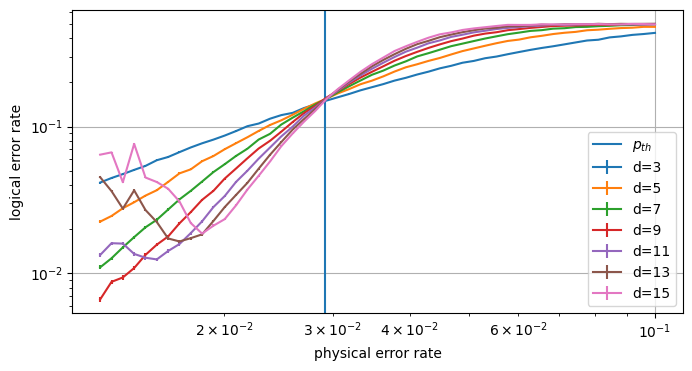

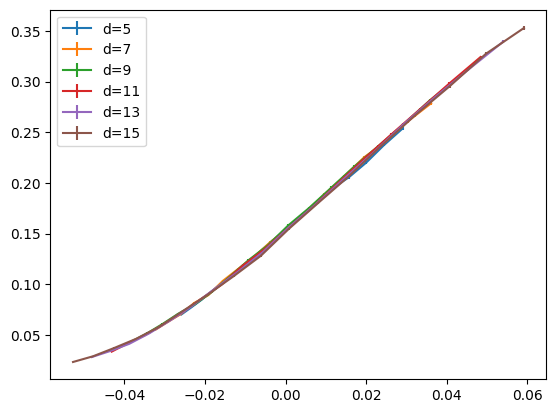

<Figure size 640x480 with 0 Axes>

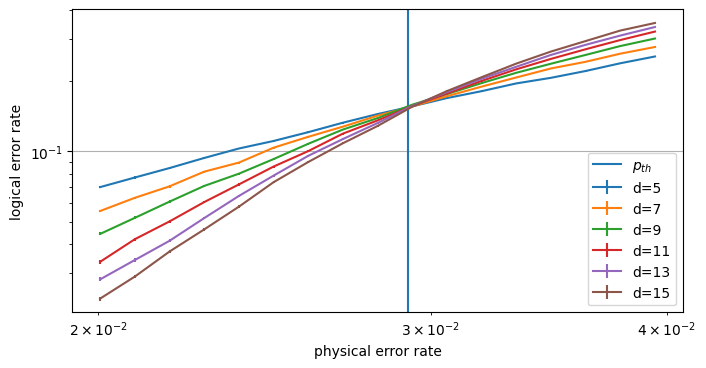

[0.02918701]
[1.5446879]


In [24]:
folder_path = r_folder_path_ML_Z
g_pth = g_pth_ml_Z

result = analysis_pipeline(
    folder_path,
    guess_pth = g_pth,
    guess_nu = g_nu,
    min_distance= min_distance, 
    p_window = p_window,
    )

print(result["p_th"])
print(result["nu_fit"])
results_ML_Z = result


       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 2.1250700369167577
             x: [ 3.323e-02  7.302e-01]
           nit: 59
          nfev: 123
 final_simplex: (array([[ 3.323e-02,  7.302e-01],
                       [ 3.323e-02,  7.302e-01],
                       [ 3.323e-02,  7.302e-01]]), array([ 2.125e+00,  2.125e+00,  2.125e+00]))
[0.03323128]
[0.0003242]


<Figure size 640x480 with 0 Axes>

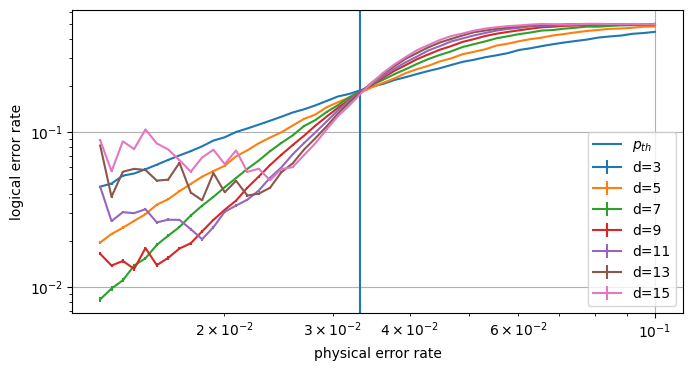

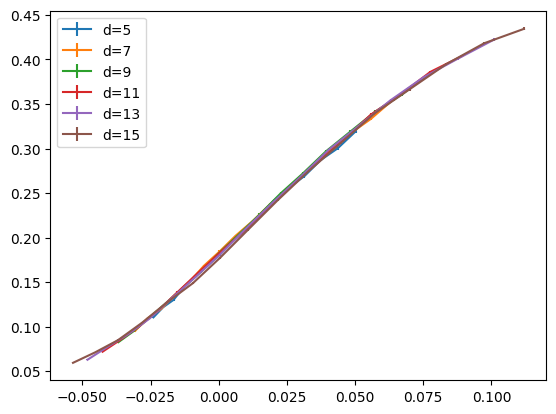

<Figure size 640x480 with 0 Axes>

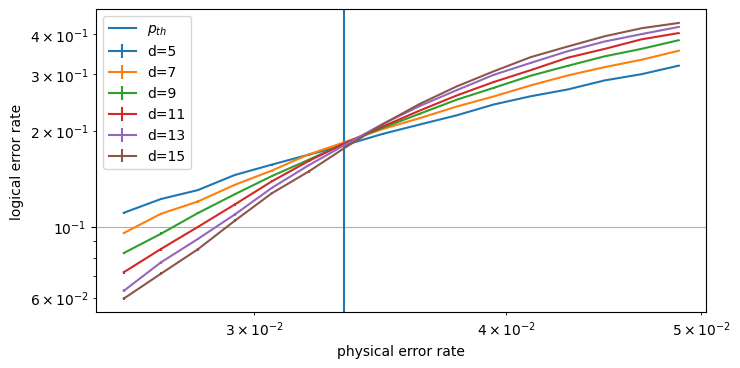

[0.03323128]
[1.36949574]


In [25]:
folder_path = r_folder_path_ML_X 
g_pth = g_pth_ml_X

result = analysis_pipeline(
    folder_path = folder_path,
    guess_pth = g_pth,
    guess_nu = g_nu,
    min_distance= min_distance, 
    p_window = p_window,
    )

print(result["p_th"])
print(result["nu_fit"])
results_ML_X = result


       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 2.4161705520322188
             x: [ 2.724e-02  6.740e-01]
           nit: 52
          nfev: 98
 final_simplex: (array([[ 2.724e-02,  6.740e-01],
                       [ 2.724e-02,  6.740e-01],
                       [ 2.724e-02,  6.740e-01]]), array([ 2.416e+00,  2.416e+00,  2.416e+00]))
[0.02723691]
[0.00032433]


<Figure size 640x480 with 0 Axes>

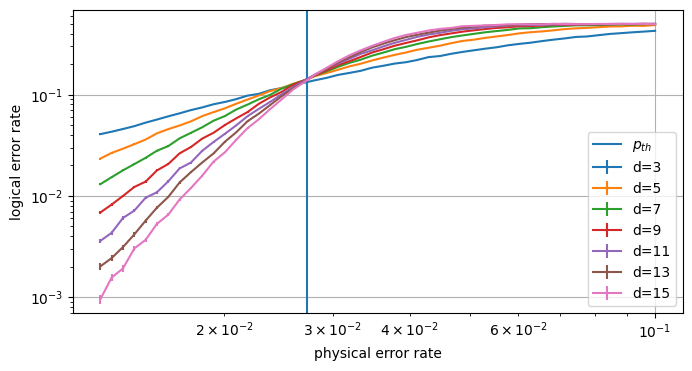

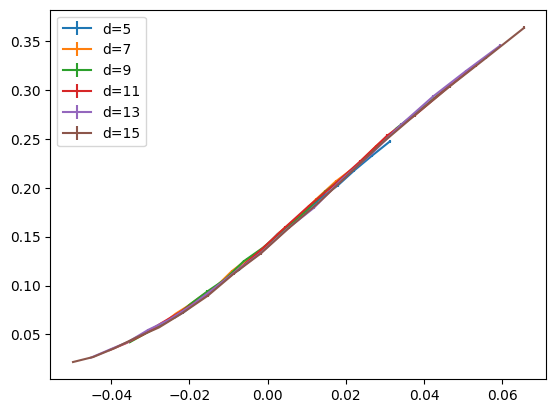

<Figure size 640x480 with 0 Axes>

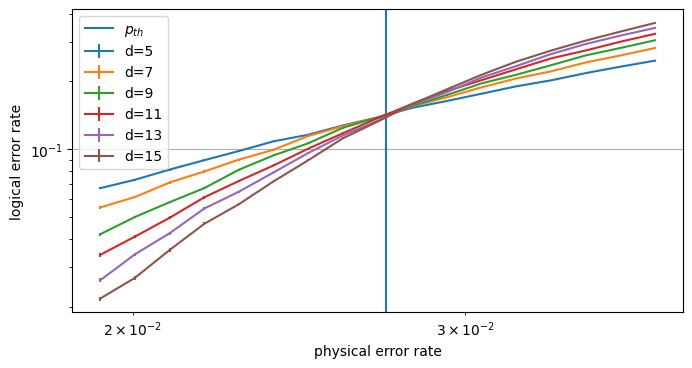

[0.02723691]
[1.48360928]


In [26]:
folder_path = r_folder_path_MWPM_Z 
g_pth = g_pth_mwpm_Z

result = analysis_pipeline(
    folder_path = folder_path,
    guess_pth = g_pth,
    guess_nu = g_nu,
    min_distance= min_distance, 
    p_window =  p_window,
    )

print(result["p_th"])
print(result["nu_fit"])
results_MWPM_Z= result


       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 2.8856874362257408
             x: [ 3.279e-02  7.469e-01]
           nit: 50
          nfev: 98
 final_simplex: (array([[ 3.279e-02,  7.469e-01],
                       [ 3.279e-02,  7.469e-01],
                       [ 3.279e-02,  7.469e-01]]), array([ 2.886e+00,  2.886e+00,  2.886e+00]))
[0.03278598]
[0.00018869]


<Figure size 640x480 with 0 Axes>

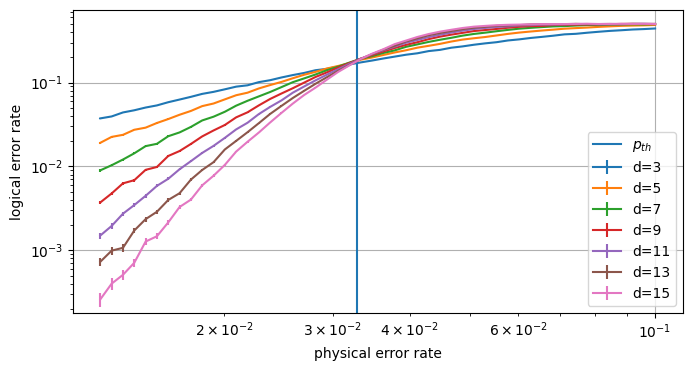

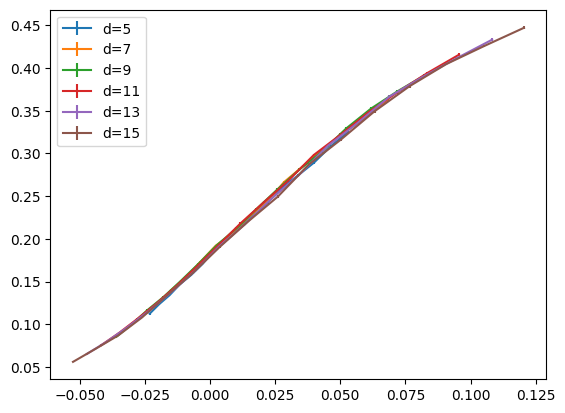

<Figure size 640x480 with 0 Axes>

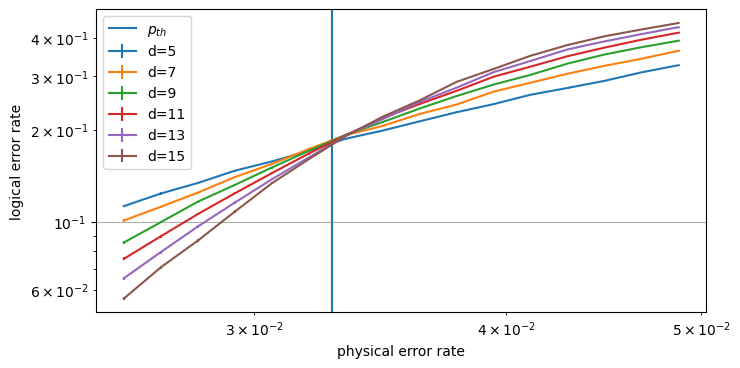

[0.03278598]
[1.33888161]


In [27]:
folder_path = r_folder_path_MWPM_X 
g_pth = g_pth_mwpm_X 

result = analysis_pipeline(
    folder_path = folder_path,
    guess_pth = g_pth,
    guess_nu = g_nu,
    min_distance= min_distance, 
    p_window =  p_window,
    )

print(result["p_th"])
print(result["nu_fit"])
results_MWPM_X = result

## Thresholds Results (1 round circ noise)

In [28]:
# collection of all threshold:
results = [results_ML_Z, results_ML_X, results_MWPM_Z, results_MWPM_X]
names = ["ML Z", "ML X", "MWPM Z", "MWPM X"]

for i in range(len(names)):
    print(f"For {names[i]}: threshold = {results[i]["p_th"][0]*10**2:.3f} +- {results[i]["err_p_th"][0]*10**2:.3f}") 



For ML Z: threshold = 2.919 +- 0.027
For ML X: threshold = 3.323 +- 0.032
For MWPM Z: threshold = 2.724 +- 0.032
For MWPM X: threshold = 3.279 +- 0.019


X error Threshold seems to be higher. 
Does this fit expectation? 

Z errors corrected first => more not tracked errors introduce by circ noise => residual error is higher => fits expectations.

## Varying parameters

In [29]:
# as collections
folder_names = [r_folder_path_ML_Z, r_folder_path_ML_X, r_folder_path_MWPM_Z, r_folder_path_MWPM_X]
names = ["ML Z", "ML X", "MWPM Z", "MWPM X"]

g_pths = [g_pth_ml_Z, g_pth_ml_X, g_pth_mwpm_Z, g_pth_mwpm_X] 

g_nus = [g_nu] * 4

In [30]:
# Varying distance
min_distances = [5,7,9]
n_distances = 3

window_distance = 2 * n_distances  

p_th_varied = np.zeros((len(min_distances), len(folder_names)))
err_p_th_varied = np.zeros((len(min_distances), len(folder_names)))
nu_fit_varied = np.zeros((len(min_distances), len(folder_names))) 
for j in range(len(min_distances)):
    for i in range(len(folder_names)):
        result = analysis_pipeline(
            folder_path = folder_names[i],
            guess_pth = g_pths[i],
            guess_nu = g_nus[i],
            min_distance = [min_distances[j]], 
            max_distance = [min_distances[j] + window_distance],
            p_window= p_window,
            plots=False,
            )

        p_th_varied[j,i] =  result["p_th"][0]
        err_p_th_varied[j,i] =  result["err_p_th"][0]
        nu_fit_varied[j,i] = result["nu_fit"][0]


       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 1.3834232755989704
             x: [ 2.900e-02  6.904e-01]
           nit: 60
          nfev: 127
 final_simplex: (array([[ 2.900e-02,  6.904e-01],
                       [ 2.900e-02,  6.904e-01],
                       [ 2.900e-02,  6.904e-01]]), array([ 1.383e+00,  1.383e+00,  1.383e+00]))
[0.02900024]
[0.00047033]

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 1.0015680310793935
             x: [ 3.292e-02  7.384e-01]
           nit: 31
          nfev: 62
 final_simplex: (array([[ 3.292e-02,  7.384e-01],
                       [ 3.292e-02,  7.384e-01],
                       [ 3.292e-02,  7.385e-01]]), array([ 1.002e+00,  1.002e+00,  1.002e+00]))
[0.03292075]
[0.00028924]

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 1.5503841275499626
             x

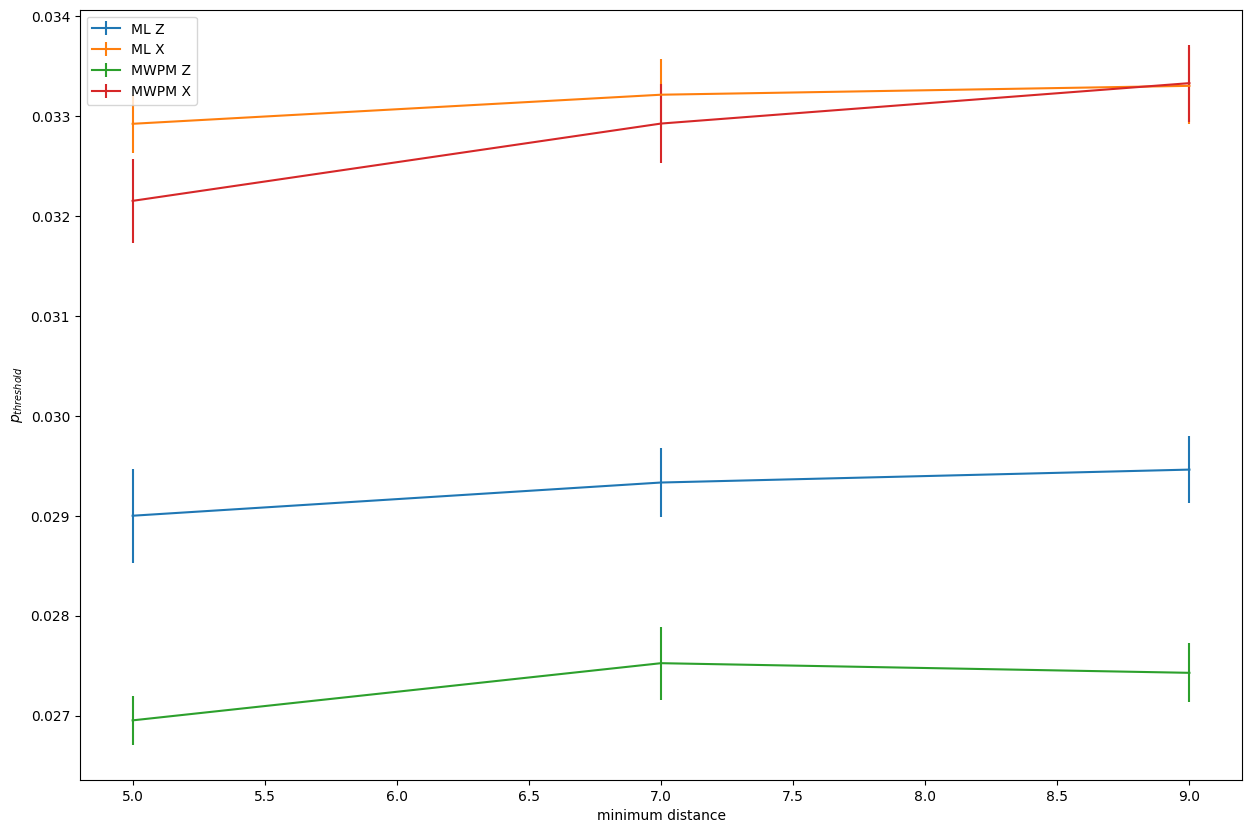

In [31]:
plt.figure(figsize=(15,10))
plt.xlabel("minimum distance")
for i in range(len(folder_names)):
    plt.errorbar(min_distances,p_th_varied[:,i], yerr=err_p_th_varied[:,i],label=names[i])
plt.ylabel("$p_{threshold}$")
# plt.yscale("log")
plt.legend()
plt.show()